<a href="https://colab.research.google.com/github/DreamTeam-10/AI-Security-Governance/blob/main/case_study_04_knn_poisoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 04: When a Model Remembers the Attacker Too

### An illustrative scenario, built from my AI/ML studies

**Companion to:** `case-studies/04-knn-training-data-poisoning/README.md` in the AI-Security-Governance repo.

This notebook uses a k-Nearest Neighbors (KNN) digit classifier to show what happens when the data a model remembers cannot be trusted.

KNN does not learn parameters the way a neural network does. It simply remembers every example it was shown and compares new inputs against them. That simplicity is exactly what makes it worth a closer look here.


## Setup
Using `sklearn.datasets.load_digits()`, a smaller version of the digit dataset I used originally (8x8 images instead of 28x28, about 1,800 examples instead of 70,000). No internet connection needed, and the same attack works no matter the dataset size.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target.astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Training set: {len(X_train)} points  |  Test set: {len(X_test)} points')


Training set: 1257 points  |  Test set: 540 points


## Step 1: Baseline model
The same simple setup I started with: train on the training data, then test on digits the model has never seen.


In [ ]:
baseline_model = KNeighborsClassifier(n_neighbors=1)
baseline_model.fit(X_train, y_train)
baseline_acc = baseline_model.score(X_test, y_test)
print(f'Baseline test accuracy: {baseline_acc:.4f}')


Baseline test accuracy: 0.9833


## Step 2: Why this matters for a real deployment
Picture this same model running in production: a bank's check reader, a postal sorter, a form-processing tool. The training data is not frozen at launch. It gets updated over time, often from vendor feedback, crowd labeling, or user corrections. That update path is what this notebook is really about.

Why this matters more for KNN than for a neural network: a neural network has to be **retrained** before new data changes anything, and that retraining is usually a visible, reviewed step. KNN skips all of that. The moment a bad example is added to its memory, it becomes live in production for the very next prediction. There is nothing to catch in a review, because there is no review step.

## Step 3: A targeted attack on one input
The simplest version of this attack: the attacker has a copy of one specific input they want misread, say, a customer's handwritten 7 on a check, and adds an identical copy to the training data under the wrong label. Since this is a 1-Nearest Neighbor model, that single point becomes the closest match for that exact input every time.


In [ ]:
# Pick a real test-set '7' as our target -- the attacker's goal is to make
# this specific input misclassify, without disturbing overall accuracy.
target_idx = np.where(y_test == '7')[0][0]
target_image = X_test[target_idx]

print('True label:', y_test[target_idx])
print('Baseline prediction:', baseline_model.predict([target_image])[0])

# Poison: insert an exact copy of the target image into training data,
# mislabeled as '8'. No retraining pipeline, no review -- just an append.
X_poisoned = np.vstack([X_train, target_image])
y_poisoned = np.append(y_train, '8')

poisoned_model = KNeighborsClassifier(n_neighbors=1)
poisoned_model.fit(X_poisoned, y_poisoned)

poisoned_acc = poisoned_model.score(X_test, y_test)
print(f'\nOverall accuracy after poisoning: {poisoned_acc:.4f}  (baseline was {baseline_acc:.4f})')
print('Prediction on target after poisoning:', poisoned_model.predict([target_image])[0])


True label: 7
Baseline prediction: 7

Overall accuracy after poisoning: 0.9815  (baseline was 0.9833)
Prediction on target after poisoning: 8


**The result that matters:** overall accuracy barely moves. A dashboard tracking average accuracy would not catch this. But the targeted input now misreads every time. This is a quiet, surgical attack. It looks like nothing changed, because almost nothing did.


## Step 4: A more realistic version
In practice, an attacker won't have pixel-perfect access to a specific future input. A more realistic version: craft several *lookalike* examples of the target class (small random perturbations of real training '7's) and mislabel all of them as '8'. This tests whether the attack still works without an exact match.


In [ ]:
rng = np.random.default_rng(7)
seven_examples = X_train[y_train == '7'][:5]
crafted = np.clip(seven_examples + rng.normal(0, 0.5, seven_examples.shape), 0, 16)

X_poisoned2 = np.vstack([X_train, crafted])
y_poisoned2 = np.append(y_train, ['8'] * len(crafted))

poisoned_model2 = KNeighborsClassifier(n_neighbors=1)
poisoned_model2.fit(X_poisoned2, y_poisoned2)
poisoned_acc2 = poisoned_model2.score(X_test, y_test)

test_sevens = X_test[y_test == '7']
preds = poisoned_model2.predict(test_sevens)
flipped = np.sum(preds == '8')

print(f'Poison points inserted: {len(crafted)}  (out of {len(y_poisoned2)} total training points, '
      f'{100*len(crafted)/len(y_poisoned2):.2f}%)')
print(f'Overall accuracy: {poisoned_acc2:.4f}  (baseline was {baseline_acc:.4f})')
print(f'Of {len(test_sevens)} real 7s in the test set, {flipped} are now misclassified as 8')


Poison points inserted: 5  (out of 1262 total training points, 0.40%)
Overall accuracy: 0.9778  (baseline was 0.9833)
Of 55 real 7s in the test set, 3 are now misclassified as 8


## Step 5: Visualize the poison
What the attack actually looks like: the crafted lookalikes next to real 7s and real 8s. To a human reviewer skimming a batch of new training images, these should not look obviously wrong.


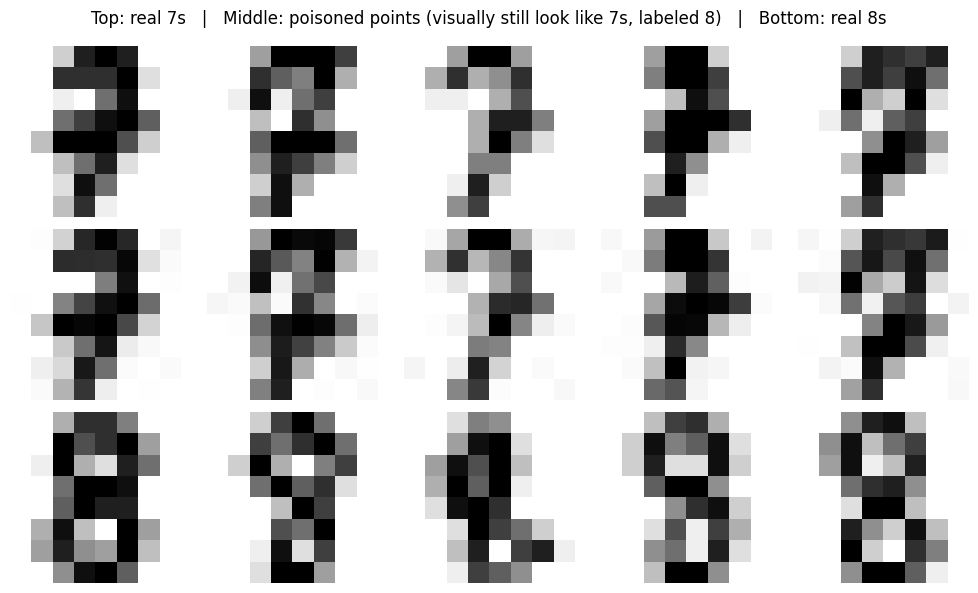

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i in range(5):
    axes[0, i].imshow(seven_examples[i].reshape(8, 8), cmap='gray_r')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('real 7s', fontsize=10)

for i in range(5):
    axes[1, i].imshow(crafted[i].reshape(8, 8), cmap='gray_r')
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('crafted, labeled 8', fontsize=10)

real_eights = X_train[y_train == '8'][:5]
for i in range(5):
    axes[2, i].imshow(real_eights[i].reshape(8, 8), cmap='gray_r')
    axes[2, i].axis('off')
axes[2, 0].set_ylabel('real 8s', fontsize=10)

fig.suptitle('Top: real 7s   |   Middle: poisoned points (visually still look like 7s, labeled 8)   |   Bottom: real 8s')
plt.tight_layout()
plt.show()


In [ ]:
An oversold one: this simple check catches every poisoned point in this demo, 100% recall, but it also flags some legitimate training examples as false positives. Those false positives are worth looking at directly:

## Step 6: A defense that catches it early
This is the same principle as the entropy-guard script in case study 03 and the policy gate in the agentic case studies: **catch the bad input at the boundary where it enters the trusted store, not after.**
The check: for every candidate point claiming a label, find its k nearest neighbors among the existing trusted training set. If most of those neighbors disagree with the claimed label, the point is suspicious, flag it for human review before it's ever added.


In [ ]:
def flag_suspicious_points(X_all, y_all, k=5, threshold=0.4):
    """
    Flags points whose k nearest neighbors mostly disagree with the
    point's own claimed label -- a proxy for 'this doesn't belong here'.
    """
    checker = KNeighborsClassifier(n_neighbors=k + 1)  # +1 to exclude self-match
    checker.fit(X_all, y_all)
    flagged = []
    for i in range(len(X_all)):
        _, idxs = checker.kneighbors([X_all[i]])
        neighbor_labels = y_all[idxs[0][1:]]
        claimed = y_all[i]
        agreement = np.mean(neighbor_labels == claimed)
        if agreement < threshold:
            flagged.append((i, claimed, agreement))
    return flagged

flagged = flag_suspicious_points(X_poisoned2, y_poisoned2, k=5)
poison_indices = set(range(len(y_train), len(y_poisoned2)))
caught = [f for f in flagged if f[0] in poison_indices]
false_positives = [f for f in flagged if f[0] not in poison_indices]

print(f'Total points flagged for review: {len(flagged)}')
print(f'Actual poison points caught: {len(caught)} / {len(crafted)}')
print(f'False positives (legitimate points flagged): {len(false_positives)}')


Total points flagged for review: 15
Actual poison points caught: 5 / 5
False positives (legitimate points flagged): 10


Honest result, not an oversold one: this simple check catches every poisoned point in this demo, 100% recall, but it also flags some legitimate training examples as false positives. Those false positives are worth looking at directly:

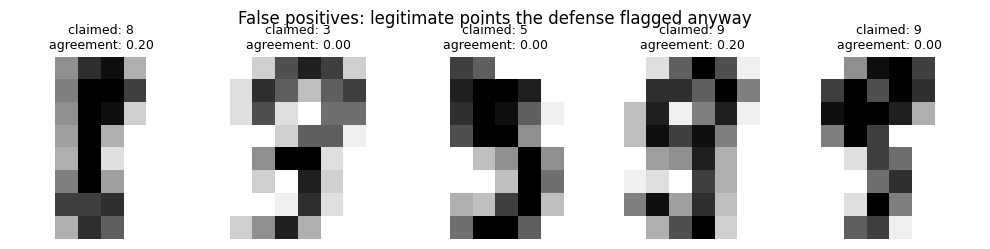

In [ ]:
fig, axes = plt.subplots(1, min(5, len(false_positives)), figsize=(10, 2.5))
if len(false_positives) == 1:
    axes = [axes]
for ax, (idx, label, agreement) in zip(axes, false_positives[:5]):
    ax.imshow(X_poisoned2[idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'claimed: {label}\nagreement: {agreement:.2f}', fontsize=9)
    ax.axis('off')
fig.suptitle('False positives: legitimate points the defense flagged anyway')
plt.tight_layout()
plt.show()


This is the same kind of mixup I saw in my own confusion matrix results: some real handwriting genuinely sits close to another digit's boundary. A label-consistency check trades a few false positives on naturally confusing inputs for catching ones that were planted on purpose. That is a real tradeoff, not a free win. In production this becomes a human review queue, not an automatic rejection, the same pattern used elsewhere in this
 repo.

## Framework mapping

| Framework | Mapping | Rationale |
|---|---|---|
| MITRE ATLAS | Poison Training Data (closest cataloged technique; verify exact ID at atlas.mitre.org) | Attacker directly manipulates the trusted training set, not the model's runtime input |
| OWASP LLM Top 10 | LLM05:2026 Data and Model Poisoning | Same root pattern OWASP catalogs for LLMs applies directly to any model that learns (or, for KNN, stores) from an updatable training set |
| MITRE D3FEND | Harden (input validation family) | The label-consistency check above is a Harden-category control at the ingestion boundary |
| NIST AI RMF | Manage function | The core governance gap is the absence of a control gate on training-data updates, not a one-time deployment decision |
| GDPR | Article 5 (data minimization), Article 32 (security of processing) | KNN's verbatim storage of training data means any PII in that data, e.g. real signatures, persists as a queryable, extractable asset for the life of the model |

Framework versions move fast. Check the current ones in `framework-reference/framework-reference.md` before citing anything here externally.

## The solution

This is preventable, and it does not need exotic tooling. A few real, production tools already handle this:

- **Cleanlab**, an open source tool built to find mislabeled and suspicious examples in a dataset before they cause harm.
- **DVC (Data Version Control)**, which lets a team version and roll back training data the same way they version code.
- **TensorFlow Data Validation (TFDV) and Alibi Detect**, which catch statistical anomalies and drift automatically.

Practical steps for a team:
1. Add a check between data received and data live, even a simple label-consistency check like the one above.
2. Version training data like source code, so any update can be reviewed or rolled back.
3. Don't rely on overall accuracy as the only signal. Watch for small, targeted shifts too.

Who should be involved: Data Science and ML Engineering own the pipeline and would wire in a tool like this. Security Engineering treats the training data path as an attack surface. Compliance and GRC track where training data comes from, especially anything that looks like personal information. Product owners decide how much risk is acceptable for a model touching real transactions.

## Governance questions
1. If your training data pipeline accepts periodic updates (vendor feedback, user corrections, crowd labeling), is there a human review or automated check between update received and update live in production, or is the update path itself the deployment path?
2. Would your monitoring catch a poisoning attack that barely moves aggregate accuracy but reliably misclassifies a small, targeted set of inputs?
3. Does your model's training data contain information (signatures, handwriting, biometric-adjacent data) that would be a privacy problem if an attacker could extract it back out through queries alone?

---
*Notebook built as the companion artifact to case-studies/04-knn-training-data-poisoning/README.md in DreamTeam-10/AI-Security-Governance. Built on the KNN digit classifier from my AI/ML studies.*